# LaneSegNet Demo Inference

This notebook demonstrates how to run inference on a single batch using a trained LaneSegNet model.

In [1]:
import os
import torch
import mmcv
from mmcv import Config
from mmcv.parallel import MMDataParallel
from mmcv.runner import load_checkpoint
from mmdet3d.datasets import build_dataloader, build_dataset
from mmdet3d.models import build_model
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Import BEV feature hooks
from bev_feature_hooks import BEVFeatureHook, visualize_bev_features, visualize_bev_features_summary

## 1. Configuration and Setup

In [2]:
# Config and checkpoint paths
config_path = 'projects/configs/lanesegnet_r50_8x1_24e_olv2_subset_A_mapele_bucket.py'
checkpoint_path = 'lanesegnet_r50_2x2_24e_olv2_subset_A_mapele_bucket.pth'

# Load config
cfg = Config.fromfile(config_path)

# Set cudnn_benchmark
if cfg.get('cudnn_benchmark', False):
    torch.backends.cudnn.benchmark = True

cfg.model.pretrained = None

# Use test dataset
cfg.data.test.test_mode = True
samples_per_gpu = 1  # Single batch

print(f"Config loaded from: {config_path}")
print(f"Dataset: {cfg.data.test.ann_file}")
print(f"Model type: {cfg.model.type}")

Config loaded from: projects/configs/lanesegnet_r50_8x1_24e_olv2_subset_A_mapele_bucket.py
Dataset: data/OpenLane-V2/data_dict_subset_A_val_ls.pkl
Model type: LaneSegNetMapElementBucket


## 2. Build Dataset and Dataloader

In [3]:
# Build the dataset
dataset = build_dataset(cfg.data.test)
print(f"Dataset size: {len(dataset)}")

# Build dataloader
data_loader = build_dataloader(
    dataset,
    samples_per_gpu=samples_per_gpu,
    workers_per_gpu=0,  # Set to 0 for debugging
    dist=False,
    shuffle=False,
)

print(f"Dataloader created with batch size: {samples_per_gpu}")

Dataset size: 4806
Dataloader created with batch size: 1


## 3. Build and Load Model

In [5]:
# Build the model
model = build_model(cfg.model, test_cfg=cfg.get('test_cfg'))

# Load checkpoint
checkpoint = load_checkpoint(model, checkpoint_path, map_location='cpu')

# Set model classes
if 'CLASSES' in checkpoint.get('meta', {}):
    model.CLASSES = checkpoint['meta']['CLASSES']
else:
    model.CLASSES = dataset.CLASSES

print(f"Model classes: {model.CLASSES}")

# Move model to GPU and set to eval mode
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = MMDataParallel(model, device_ids=[0])
model.eval()

print(f"Model loaded on device: {device}")

load checkpoint from local path: lanesegnet_r50_2x2_24e_olv2_subset_A_mapele_bucket.pth
Model classes: ['lane_segment', 'ped_crossing', 'road_boundary']
Model loaded on device: cuda:0


## 4. Setup BEV Feature Hooks

In [6]:
# Create and register BEV feature hook
bev_hook = BEVFeatureHook()
bev_hook.register(model)

print("BEV feature hook registered successfully!")

✓ BEV constructor hook registered
BEV feature hook registered successfully!


## 5. Run Inference on a Single Batch

## 6. Visualize BEV Features

In [9]:
# Get the captured BEV features from the hook
bev_features = bev_hook.get_latest_features()
print(bev_features)

if bev_features is not None:
    print(f"BEV features captured!")
    print(f"Shape: {bev_features.shape}")
    print(f"Min: {bev_features.min():.4f}, Max: {bev_features.max():.4f}")
    print(f"Mean: {bev_features.mean():.4f}, Std: {bev_features.std():.4f}")
else:
    print("No BEV features captured")

None
No BEV features captured


In [15]:
# Visualize BEV features - individual channels

if bev_features is not None:
    # Get BEV dimensions from config
    bev_h = cfg.model.bev_constructor.bev_h
    bev_w = cfg.model.bev_constructor.bev_w
    
    visualize_bev_features(
        bev_features,
        num_channels=16,  # Show 16 feature channels
        figsize=(24, 12),
        bev_h=bev_h,
        bev_w=bev_w
    )

# Visualize BEV features summary with statistics
if bev_features is not None:
    bev_h = cfg.model.bev_constructor.bev_h
    bev_w = cfg.model.bev_constructor.bev_w
    
    visualize_bev_features_summary(
        bev_features,
        bev_h=bev_h,
        bev_w=bev_w,
        figsize=(18, 10)
    )

## 7. Visualize Input Images

In [16]:
# Get image metadata
img_metas = data['img_metas'].data[0][0]
img_filenames = img_metas['filename']

print(f"Number of camera views: {len(img_filenames)}")
print("Camera filenames:")
for i, filename in enumerate(img_filenames):
    print(f"  Camera {i}: {filename}")

Number of camera views: 7
Camera filenames:
  Camera 0: data/OpenLane-V2/val/10000/image/ring_front_center/315969904399927214.jpg
  Camera 1: data/OpenLane-V2/val/10000/image/ring_front_left/315969904387425431.jpg
  Camera 2: data/OpenLane-V2/val/10000/image/ring_front_right/315969904362451247.jpg
  Camera 3: data/OpenLane-V2/val/10000/image/ring_rear_left/315969904357428273.jpg
  Camera 4: data/OpenLane-V2/val/10000/image/ring_rear_right/315969904392441189.jpg
  Camera 5: data/OpenLane-V2/val/10000/image/ring_side_left/315969904372412935.jpg
  Camera 6: data/OpenLane-V2/val/10000/image/ring_side_right/315969904377482497.jpg


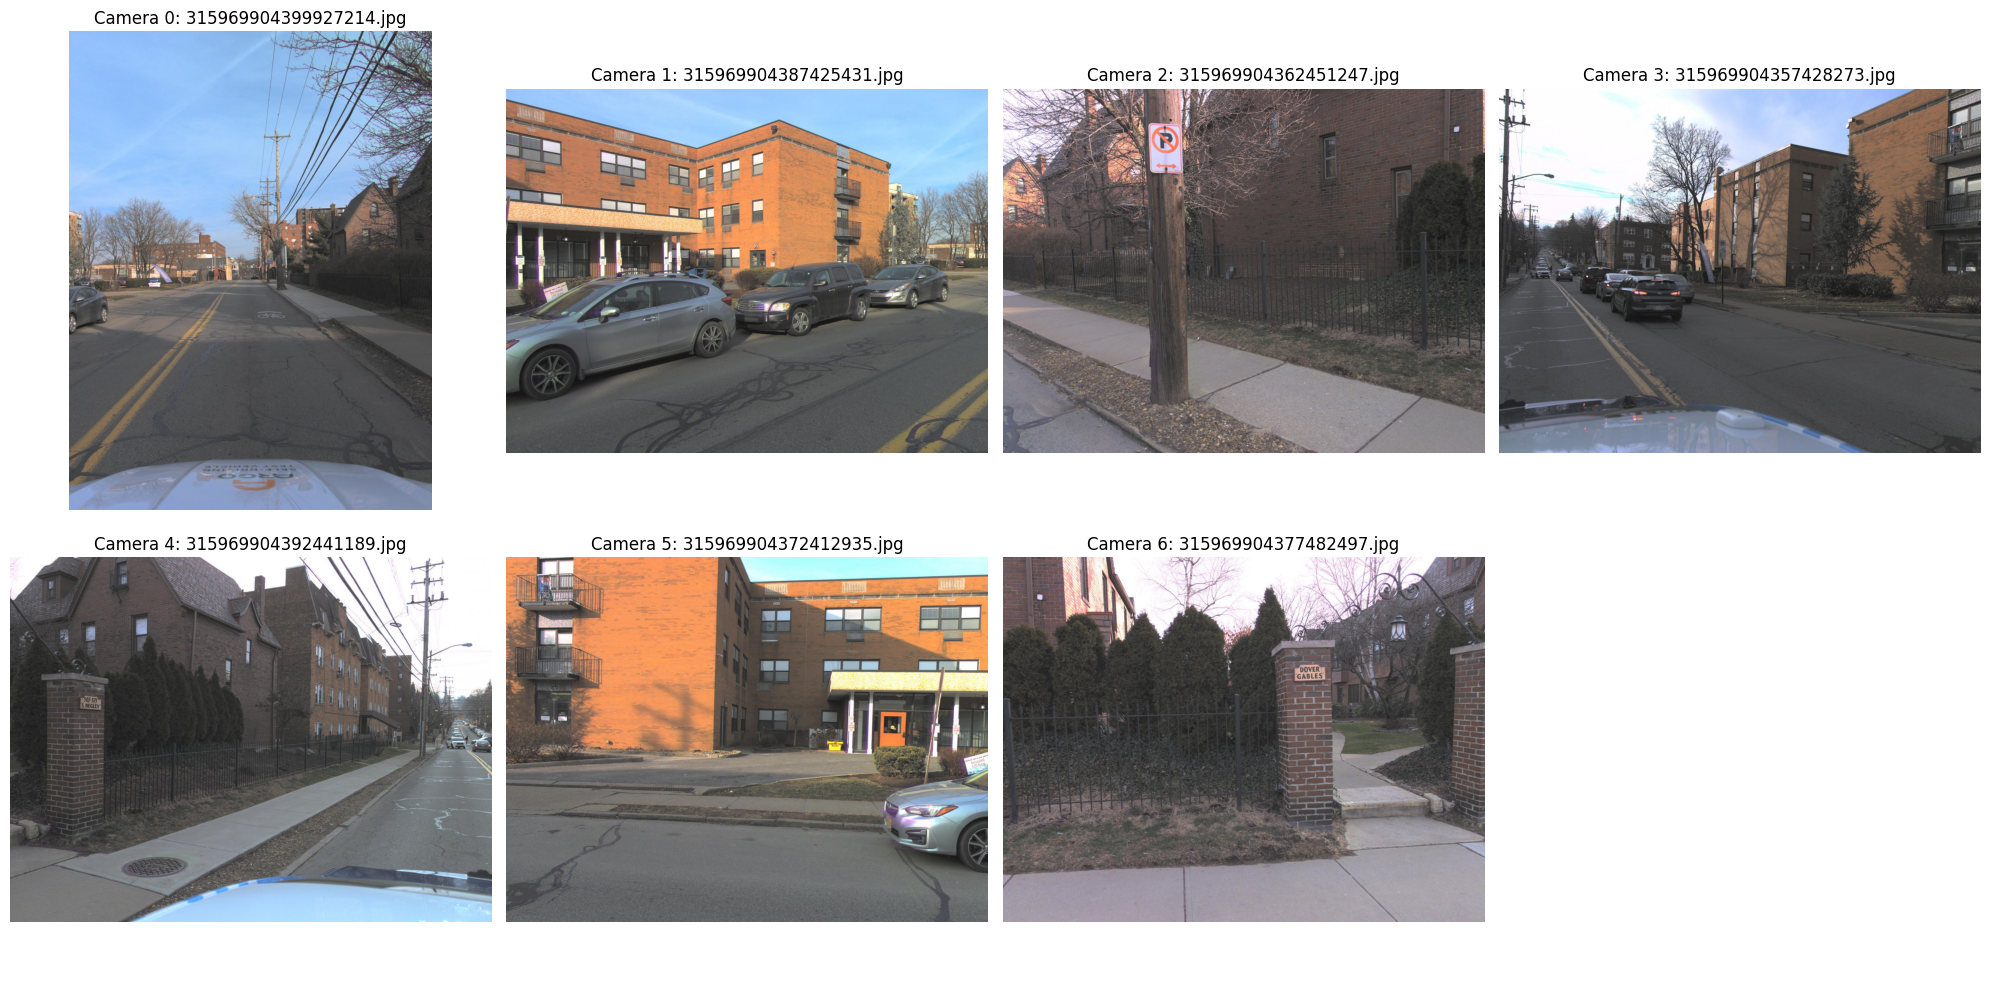

In [17]:
# Visualize all camera views
num_cams = len(img_filenames)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, filename in enumerate(img_filenames):
    if os.path.exists(filename):
        img = Image.open(filename)
        axes[i].imshow(img)
        axes[i].set_title(f'Camera {i}: {os.path.basename(filename)}')
        axes[i].axis('off')
    else:
        axes[i].text(0.5, 0.5, 'Image not found', ha='center', va='center')
        axes[i].set_title(f'Camera {i}')
        axes[i].axis('off')

# Hide extra subplot
if num_cams < 8:
    for i in range(num_cams, 8):
        axes[i].axis('off')

plt.tight_layout()
plt.show()

## 8. Analyze Detection Results

Visualizing 1 lane segments


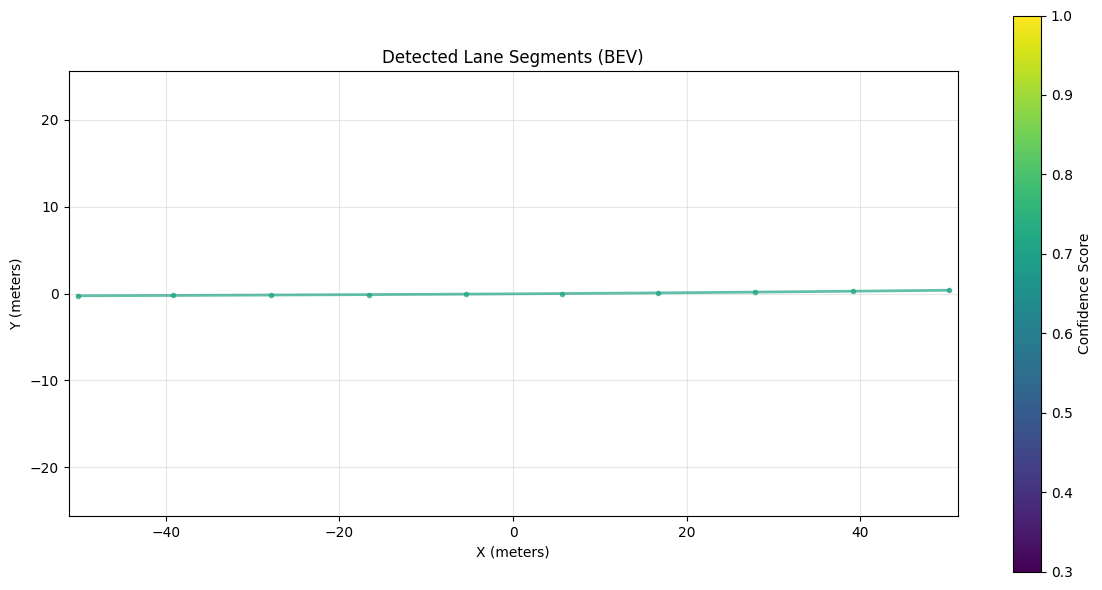

In [18]:
# Visualize detected lane segments in BEV
if lane_results is not None and len(lane_results[1]) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Get point cloud range from config
    pc_range = cfg.model.lane_head.pc_range
    
    # Plot all lanes with confidence > threshold
    lane_threshold = 0.3
    scores = lane_results[1]
    high_conf_mask = scores > lane_threshold
    
    lanes_3d = lane_results[0][high_conf_mask]
    scores_filtered = scores[high_conf_mask]
    
    # Reshape lanes to get individual points (lanes are flattened as [centerline, left, right])
    # Each lane has points_num * 3 lines (centerline, left boundary, right boundary)
    points_num = 10  # default from config
    lanes_3d = lanes_3d.reshape(-1, lanes_3d.shape[-1] // 3, 3)
    
    print(f"Visualizing {len(lanes_3d)} lane segments")
    
    for i, (lane, score) in enumerate(zip(lanes_3d, scores_filtered)):
        # lane shape: (n_points*3, 3) - need to extract centerline
        centerline = lane[:points_num]  # First points_num points are centerline
        x = centerline[:, 0]
        y = centerline[:, 1]
        
        # Plot lane with color based on confidence
        color = plt.cm.viridis(score)
        ax.plot(x, y, '-o', linewidth=2, markersize=3, color=color, alpha=0.7)
    
    # Set axis limits based on point cloud range
    ax.set_xlim(pc_range[0], pc_range[3])
    ax.set_ylim(pc_range[1], pc_range[4])
    ax.set_xlabel('X (meters)')
    ax.set_ylabel('Y (meters)')
    ax.set_title('Detected Lane Segments (BEV)')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    # Add colorbar
    sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=lane_threshold, vmax=1.0))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label('Confidence Score')
    
    plt.tight_layout()
    plt.show()
else:
    print("No lane results to visualize")

## 8. Analyze Topology Predictions


=== Lane-to-Lane Topology Matrix ===
Shape: (200, 200)
Number of lane-to-lane connections (threshold > 0.5): 2303


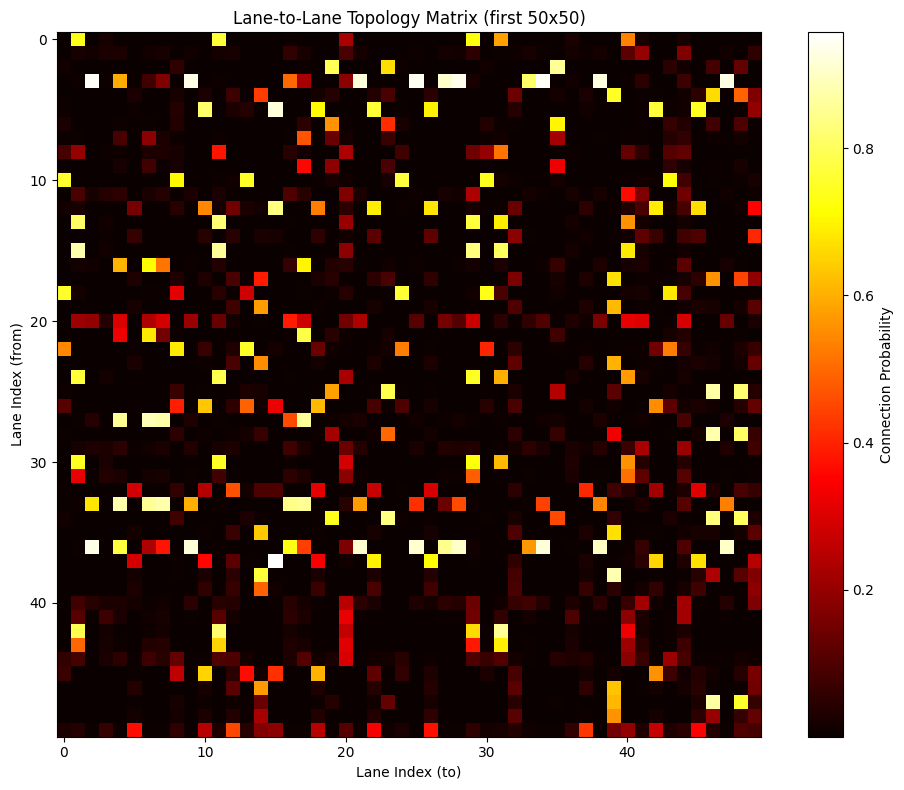


Top 10 lane-to-lane connections:
  Lane 134 -> Lane 141: 0.981
  Lane 37 -> Lane 141: 0.977
  Lane 134 -> Lane 115: 0.976
  Lane 82 -> Lane 115: 0.974
  Lane 37 -> Lane 115: 0.974
  Lane 169 -> Lane 115: 0.972
  Lane 82 -> Lane 141: 0.972
  Lane 169 -> Lane 141: 0.970
  Lane 134 -> Lane 196: 0.968
  Lane 176 -> Lane 141: 0.967


In [19]:
# Visualize lane-to-lane topology
if lsls_results is not None:
    print(f"\n=== Lane-to-Lane Topology Matrix ===")
    print(f"Shape: {lsls_results.shape}")
    
    # Apply threshold to get binary topology
    topology_threshold = 0.5
    topology_binary = (lsls_results > topology_threshold).astype(int)
    
    # Count connections
    num_connections = topology_binary.sum()
    print(f"Number of lane-to-lane connections (threshold > {topology_threshold}): {num_connections}")
    
    if num_connections > 0:
        # Show topology matrix as heatmap (first 50x50 for visibility)
        fig, ax = plt.subplots(figsize=(10, 8))
        im = ax.imshow(lsls_results[:50, :50], cmap='hot', interpolation='nearest')
        ax.set_xlabel('Lane Index (to)')
        ax.set_ylabel('Lane Index (from)')
        ax.set_title('Lane-to-Lane Topology Matrix (first 50x50)')
        plt.colorbar(im, ax=ax, label='Connection Probability')
        plt.tight_layout()
        plt.show()
        
        # Print top connections
        print("\nTop 10 lane-to-lane connections:")
        flat_indices = np.argsort(lsls_results.flatten())[::-1][:10]
        for idx in flat_indices:
            i, j = np.unravel_index(idx, lsls_results.shape)
            print(f"  Lane {i} -> Lane {j}: {lsls_results[i, j]:.3f}")

## 9. Save Results

In [20]:
# Save results to file
output_dir = 'demo_output'
os.makedirs(output_dir, exist_ok=True)

output_file = os.path.join(output_dir, 'demo_results.pkl')
mmcv.dump(result, output_file)
print(f"Results saved to: {output_file}")

# Save summary
summary = {
    'num_lanes': len(lane_results[1]) if lane_results else 0,
    'num_traffic_elements': len(bbox_results[1]) if bbox_results else 0,
    'num_areas': len(area_results[1]) if area_results else 0,
    'img_metas': img_metas,
}

summary_file = os.path.join(output_dir, 'demo_summary.json')
mmcv.dump(summary, summary_file)
print(f"Summary saved to: {summary_file}")

Results saved to: demo_output/demo_results.pkl


TypeError: <class 'type'> is unsupported for json dump

## 10. Test Multiple Batches (Optional)

In [ ]:
# Process multiple batches
num_batches = 5

all_results = []
data_iter = iter(data_loader)

print(f"Processing {num_batches} batches...\n")

for batch_idx in range(num_batches):
    try:
        data = next(data_iter)
        
        with torch.no_grad():
            result = model(return_loss=False, rescale=True, **data)
        
        all_results.append(result[0])
        
        # Print summary - use index access for list/tuple format
        num_lanes = len(result[0]['lane_results'][1]) if result[0]['lane_results'] else 0
        num_bboxes = len(result[0]['bbox_results'][1]) if result[0]['bbox_results'] else 0
        num_areas = len(result[0]['area_results'][1]) if result[0]['area_results'] else 0
        
        print(f"Batch {batch_idx + 1}: {num_lanes} lanes, {num_bboxes} traffic elements, {num_areas} areas")
        
    except StopIteration:
        print(f"Reached end of dataset at batch {batch_idx + 1}")
        break

print(f"\nProcessed {len(all_results)} batches successfully")